In [1]:
import csv, pandas, numpy, scipy, seaborn

In [2]:
# todo
# make sure the gene set are exclusive
# work on DEGs only
# expand to all non cannonical genes

In [3]:
# get cannonical HH genes based on R-HSA Hedgehog 'On' State term
with open('Reactome_Pathways_2024.txt', newline='') as f:
    reader = csv.reader(f, delimiter='\t')   # adjust delimiter
    for row in reader:
        if row[0] == "Hedgehog 'On' State":
            canonical = list(set(row[2:-1]))
            print(row, len(row))
            print(canonical, len(canonical))   

["Hedgehog 'On' State", '', 'CDON', 'CSNK1A1', 'SMURF2', 'PTCH2', 'SMURF1', 'PTCH1', 'IQCE', 'KIF7', 'RBX1', 'PSMC6', 'PSMC4', 'PSMC5', 'GAS1', 'PSMC2', 'GPR161', 'PSMC3', 'PSMC1', 'ULK3', 'SPOPL', 'GAS8', 'NUMB', 'PSMD11', 'PSMD13', 'PSMD12', 'PSMD14', 'IHH', 'CDC73', 'GRK2', 'PSMD7', 'PSMD8', 'SHH', 'BOC', 'PSMD6', 'PSMD3', 'PSMD1', 'PSMD2', 'SPOP', 'RPS27A', 'ADRM1', 'ITCH', 'EVC', 'PSMA6', 'PSMA7', 'PSMA4', 'PSMA5', 'SEM1', 'PSMA2', 'PSMA3', 'SMO', 'PSMA1', 'DZIP1', 'UBA52', 'DHH', 'CUL3', 'HHIP', 'ARRB2', 'EFCAB7', 'GLI2', 'GLI1', 'GLI3', 'PSMB7', 'PSMB5', 'PSMB6', 'PSMB3', 'UBC', 'ARRB1', 'PSMB4', 'UBB', 'KIF3A', 'PSMB1', 'PSMB2', 'SUFU', 'EVC2', ''] 76
['SMURF2', 'PSMC6', 'PSMC1', 'SHH', 'UBC', 'ITCH', 'IQCE', 'SPOP', 'SMURF1', 'GLI3', 'SMO', 'PSMC4', 'GRK2', 'PSMB7', 'PSMB6', 'CDON', 'PSMC3', 'IHH', 'CDC73', 'PTCH1', 'PSMB4', 'SUFU', 'ADRM1', 'PSMD8', 'SPOPL', 'GPR161', 'GAS8', 'PSMA6', 'PSMD2', 'PSMA5', 'RPS27A', 'GLI2', 'EVC2', 'UBA52', 'CSNK1A1', 'PSMB2', 'PSMA2', 'PSMA1', '

In [4]:
# get the non cannonical hh based on Table 1 from 

def appender(noncanonical):
    elements = set(row[2:-1])
    print('detected category with', len(elements))
    noncanonical = noncanonical | elements
    print('current', len(noncanonical))
    print()
    return noncanonical

noncanonical = set()

categories = [
    "RAF MAP Kinase Cascade", 'MAPK1 MAPK3 Signaling', 'MAPK1 (ERK2) Activation', 'MAPK3 (ERK1) Activation'
]

with open('Reactome_Pathways_2024.txt', newline='') as f:
    reader = csv.reader(f, delimiter='\t')   # adjust delimiter
    for row in reader:
        
        # RAS-RAF-MEK-ERK: RAF MAP Kinase Cascade, 

        for category in categories:
            if category == row[0]:
                noncanonical = appender(noncanonical)
            
        # MAPK1 MAPK3 Signaling
            
noncanonical = list(noncanonical)  
print(len(noncanonical), noncanonical[:10])

detected category with 9
current 9

detected category with 271
current 271

detected category with 10
current 271

detected category with 265
current 271

271 ['DUSP7', 'EREG', 'PPP2R5D', 'IRS1', 'ADRM1', 'PRKG2', 'CAMK2B', 'GRB2', 'PSMD13', 'PTPN11']


In [5]:
# convert the two lists into ensembl
t2g_file = '/Users/adrian/software/kallisto/t2g.txt'
rosetta = pandas.read_csv(t2g_file, sep='\t', header=None)

ensembl_cannonical = []; ensembl_noncanonical = []

def converter(target):
    ensemblID = None
    conversion = list(set(rosetta[rosetta[2] == target][1].values))
    if len(conversion) == 0:
        pass
    elif len(conversion) == 1:
        ensemblID = conversion[0]
    else:
        print('ERROR')
        print(conversion)
    return ensemblID

for target in canonical:
    ensemblID = converter(target)
    if ensemblID is not None:
        ensembl_cannonical.append(ensemblID)
   
for target in noncanonical:
    ensemblID = converter(target)
    if ensemblID is not None:
        ensembl_noncanonical.append(ensemblID)

ensembl_cannonical = list(set(ensembl_cannonical))
ensembl_noncanonical = list(set(ensembl_noncanonical))
print(len(ensembl_cannonical), len(ensembl_noncanonical))

targets = list(set(ensembl_cannonical + ensembl_noncanonical))
print(len(targets))

/var/folders/zc/gkbgbc397lzgnslfwph9pg_00000gn/T/ipykernel_6728/1839607511.py:3: DtypeWarning: Columns (0: 4) have mixed types. Specify dtype option on import or set low_memory=False.
  rosetta = pandas.read_csv(t2g_file, sep='\t', header=None)


73 269
302


In [6]:
# access the expression data
expression_file = 'DESeq2_TPM_values.transcripts.tsv'
df = pandas.read_csv(expression_file, sep='\t', index_col=0)
df

,SRR24197676,SRR24197677,SRR24197678,SRR24197679,SRR24197680,SRR24197681,SRR24197682,SRR24197683,SRR24197684,SRR24197685,...,SRR24197711,SRR24197712,SRR24197713,SRR24197714,SRR24197715,SRR24197716,SRR24197717,SRR24197718,SRR24197719,SRR24197720
ENSG00000000003.15,62.858977,31.771449,34.651158,56.669103,36.806233,37.290949,29.015099,30.991532,34.584786,27.309989,...,21.302521,34.348128,46.428343,42.798327,35.598414,35.165505,42.571532,34.402216,39.400808,38.400612
ENSG00000000005.6,0.000000,0.000000,0.000000,0.000000,0.000000,0.054277,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.415614,0.426898,0.374336,0.982474,0.869173,0.849658,0.000000,0.000000,0.000000
ENSG00000000419.14,86.389186,52.971897,49.156871,88.802819,50.403289,50.543090,106.185088,96.750511,99.288102,72.090502,...,84.687112,92.001194,116.577424,109.094536,36.587173,39.257637,58.972095,87.149778,89.534716,102.261067
ENSG00000000457.14,5.287378,2.571407,1.844020,3.880388,1.776324,1.846350,2.691707,2.473953,3.164968,3.104503,...,7.300535,4.356865,5.211349,4.800627,10.021584,11.218086,13.012265,4.130994,3.278623,3.154355
ENSG00000000460.17,25.095803,16.543945,13.670647,21.423212,16.454469,16.191112,16.214193,20.278728,19.783594,14.712733,...,27.305086,28.114061,20.685985,25.562383,42.361668,39.690778,31.410296,22.912470,19.076475,23.636767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000291297.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.562361,12.954279,12.735433,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291298.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.913526,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000291299.1,1.226352,0.080083,0.475706,0.781747,0.064524,0.000000,1.196530,1.692031,1.777767,2.429043,...,1.030368,1.198862,1.482962,1.149236,3.691039,4.907918,3.477604,2.843972,1.070509,1.343788
ENSG00000291300.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.211498,0.216274,0.122587,0.105283,0.000000,0.000000


In [7]:
# subset
sub = df.loc[targets]
sub.shape

(302, 45)

In [8]:
# get the top variant genes based on log2 transformed MAD
x = numpy.log2(sub + 1.0)
mad = x.sub(x.median(axis=1), axis=0).abs().median(axis=1)
top_genes = mad.sort_values(ascending=False).head(100).index # get the the top 100 most different genes
x_top = x.loc[top_genes]

In [9]:
# row-wise z-score
row_mean = x_top.mean(axis=1)
row_std = x_top.std(axis=1, ddof=1).replace(0.0, numpy.nan)
z = x_top.sub(row_mean, axis=0).div(row_std, axis=0).fillna(0.0)

In [ ]:
conversion = list(set(rosetta[rosetta[2] == target][1].values))

In [13]:
rosetta

,0,1,2,3,4,5,6,7
0,ENST00000308647.8,ENSG00000160072.20,ATAD3B,ATAD3B-201,1,1471784,1496201,+
1,ENST00000378736.3,ENSG00000160072.20,ATAD3B,ATAD3B-202,1,1479049,1482662,+
2,ENST00000472194.6,ENSG00000160072.20,ATAD3B,ATAD3B-203,1,1478026,1497848,+
3,ENST00000474481.1,ENSG00000160072.20,ATAD3B,ATAD3B-204,1,1484569,1496201,+
4,ENST00000485748.5,ENSG00000160072.20,ATAD3B,ATAD3B-205,1,1483485,1496202,+
...,...,...,...,...,...,...,...,...
227660,ENST00000619729.1,ENSG00000277856.1,NaN,NaN,KI270726.1,26241,26534,+
227661,ENST00000612640.4,ENSG00000271254.7,NaN,NaN,KI270711.1,6101,29626,-
227662,ENST00000614336.4,ENSG00000271254.7,NaN,NaN,KI270711.1,4612,24650,-
227663,ENST00000601199.2,ENSG00000268674.2,NaN,NaN,KI270713.1,35407,35916,+


In [21]:
# bring in gene names
new_names = []
for element in z.index:
    new_names.append(list(set(rosetta[rosetta[1] == element][2]))[0])
print(len(z.index), len(new_names))

z.index = new_names

100 100


In [ ]:
# add metadata


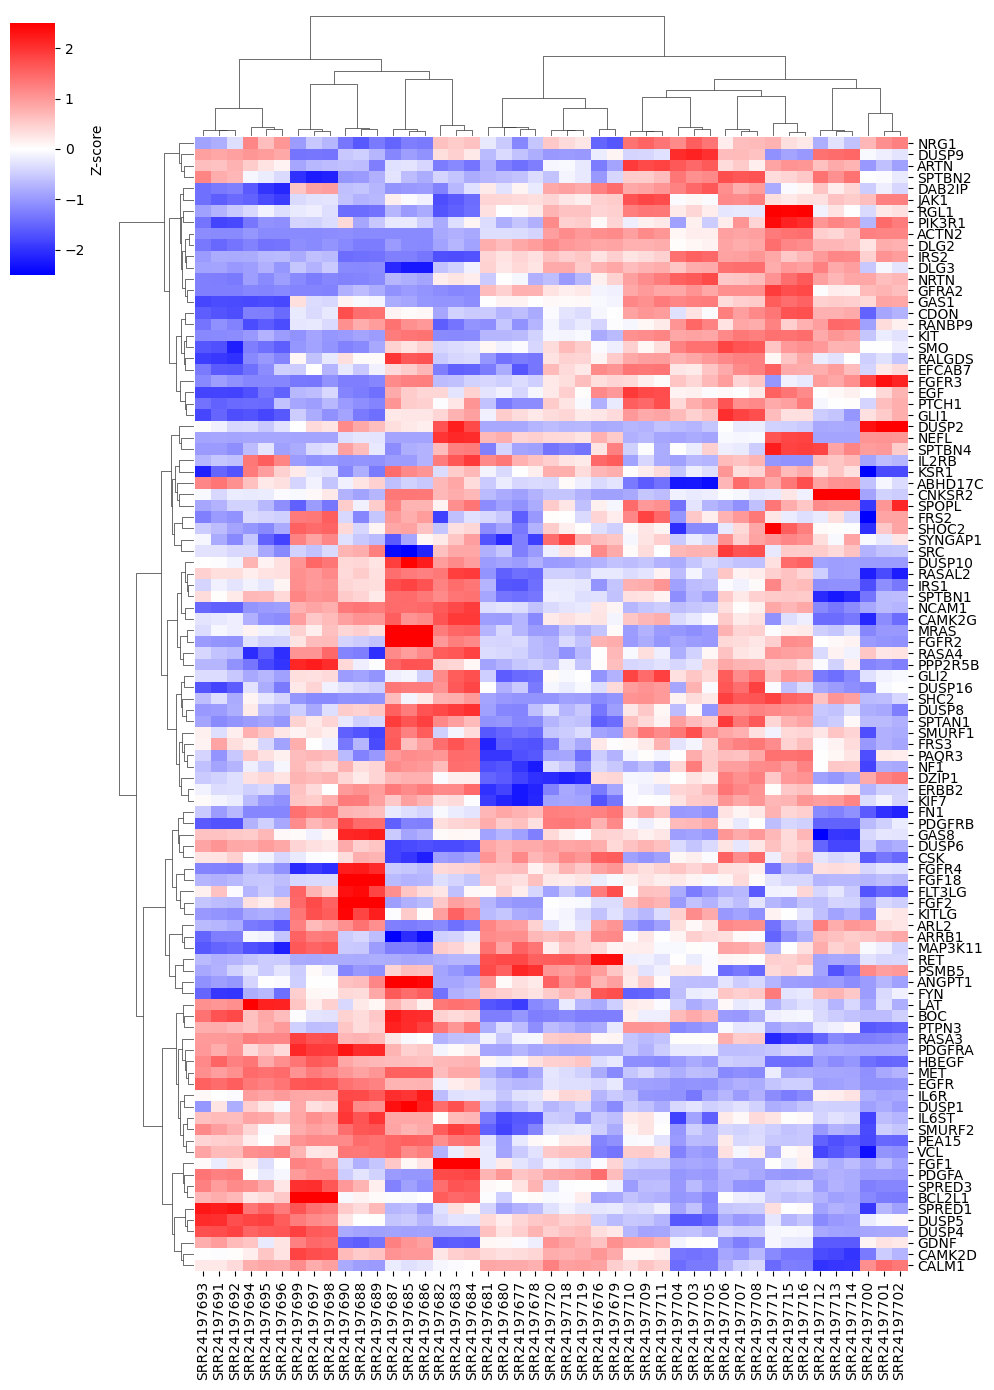

In [22]:
# euclidean ward seems to work fine
# correlation average also seems good
# correlation complete is the best with top 20
# cosine average good
g = seaborn.clustermap(
    z,
    metric='euclidean',     # distance metric
    method='ward',       # clustering method (e.g., single, complete, average, ward)
    cmap='bwr',            # color map (others: 'coolwarm', 'viridis', 'mako', 'rocket')
    standard_scale=None,    # or 0 (rows) or 1 (columns) if you didn't z-score earlier
    figsize=(9, 14),
    #col_colors=group_colors,
    #row_colors=row_colors,
    dendrogram_ratio=(0.1, 0.1),  # adjust size of dendrograms
    cbar_pos=(-0.1, 0.8, 0.05, 0.18),  # colorbar position
    xticklabels=True,
    cbar_kws={'label': 'Z-score'},
    vmin=-2.5,
    vmax=2.5,
    yticklabels=True
)